In [2]:
from pyod.utils.data import generate_data

In [1]:
import pyod
print("pyod version:", pyod.__version__)


pyod version: 2.0.5


In [5]:
#------------------------------------EX1---------------------------------

n_train = 300
n_test = 200
contamination = 0.15

X_train, X_test, y_train, y_test = generate_data(
    n_train=n_train,
    n_test=n_test,
    n_features=3,
    contamination=contamination,
    random_state=42,  
)

print(X_train.shape)  
print(X_test.shape)   
print(y_train.shape)  
print(y_test.shape)   


(300, 3)
(200, 3)
(300,)
(200,)


In [6]:
from pyod.models.ocsvm import OCSVM

contamination = 0.15  

clf = OCSVM(kernel='linear', contamination=contamination)
clf.fit(X_train)
y_pred = clf.labels_ 
y_test_pred = clf.predict(X_test)

y_test_scores = clf.decision_function(X_test)
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

bal_acc = balanced_accuracy_score(y_test, y_test_pred)

roc = roc_auc_score(y_test, y_test_scores)

print("Balanced Accuracy:", bal_acc)
print("ROC AUC:", roc)

Balanced Accuracy: 0.9833333333333334
ROC AUC: 1.0


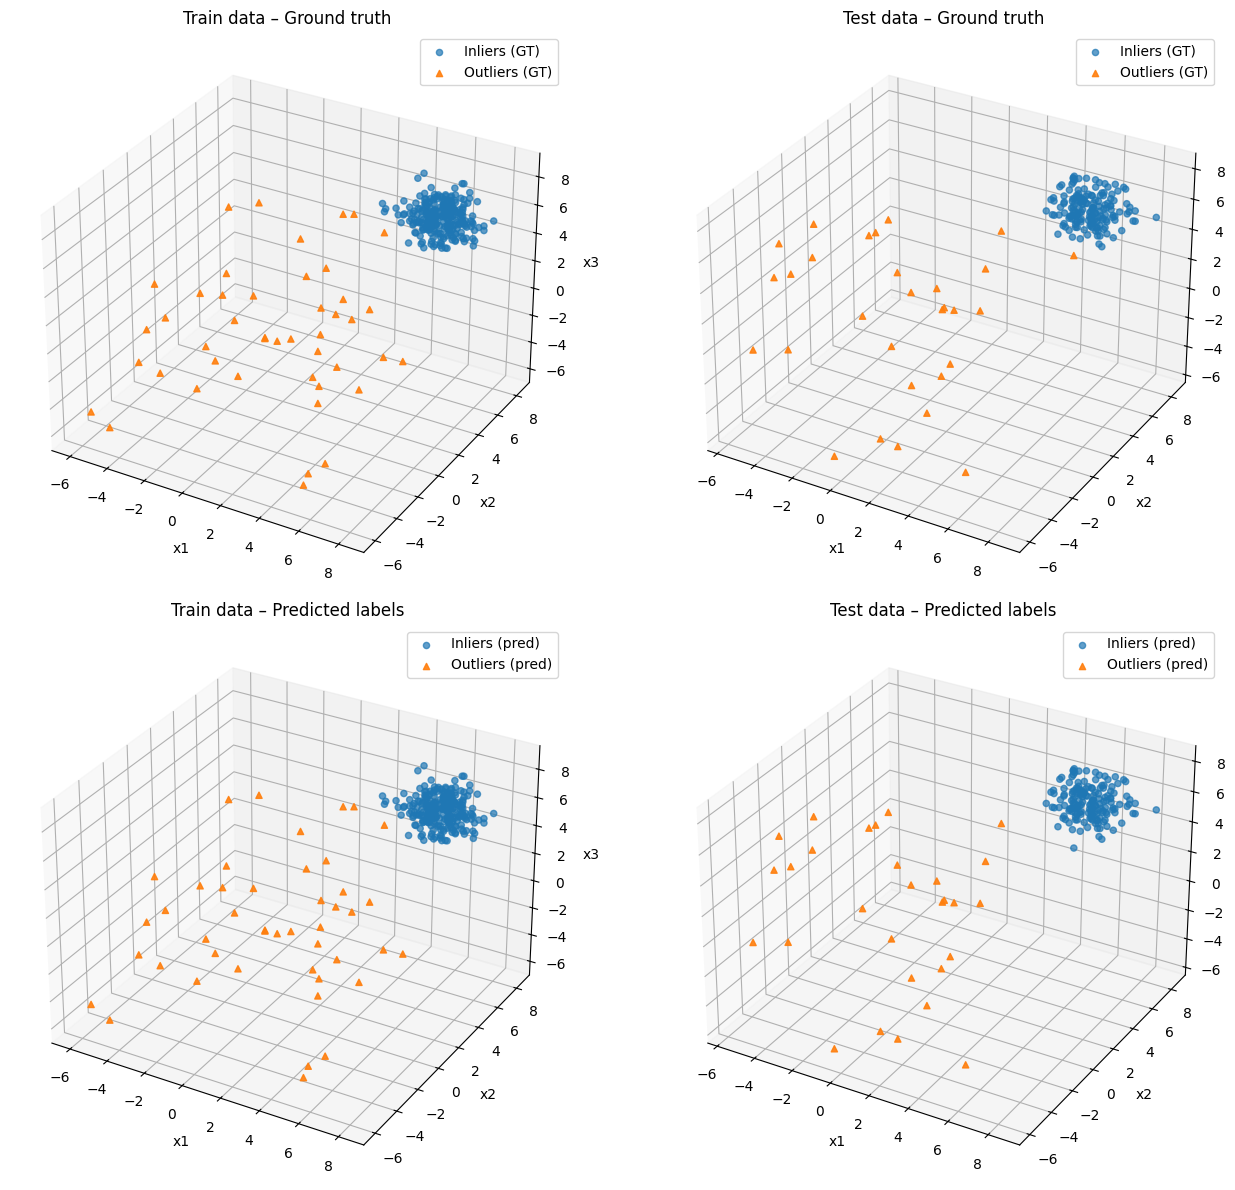

In [7]:
clf = OCSVM(kernel='linear', contamination=contamination)
clf.fit(X_train)

y_train_pred = clf.predict(X_train)
y_test_pred  = clf.predict(X_test)

y_test_scores = clf.decision_function(X_test)

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # sometimes needed for older mpl

train_in_gt = y_train == 0
train_out_gt = y_train == 1

test_in_gt = y_test == 0
test_out_gt = y_test == 1

train_in_pred = y_train_pred == 0
train_out_pred = y_train_pred == 1

test_in_pred = y_test_pred == 0
test_out_pred = y_test_pred == 1

fig = plt.figure(figsize=(14, 12))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(X_train[train_in_gt, 0], X_train[train_in_gt, 1], X_train[train_in_gt, 2],
            label='Inliers (GT)', alpha=0.7)
ax1.scatter(X_train[train_out_gt, 0], X_train[train_out_gt, 1], X_train[train_out_gt, 2],
            marker='^', label='Outliers (GT)', alpha=0.9)
ax1.set_title('Train data – Ground truth')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('x3')
ax1.legend()

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(X_test[test_in_gt, 0], X_test[test_in_gt, 1], X_test[test_in_gt, 2],
            label='Inliers (GT)', alpha=0.7)
ax2.scatter(X_test[test_out_gt, 0], X_test[test_out_gt, 1], X_test[test_out_gt, 2],
            marker='^', label='Outliers (GT)', alpha=0.9)
ax2.set_title('Test data – Ground truth')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('x3')
ax2.legend()

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(X_train[train_in_pred, 0], X_train[train_in_pred, 1], X_train[train_in_pred, 2],
            label='Inliers (pred)', alpha=0.7)
ax3.scatter(X_train[train_out_pred, 0], X_train[train_out_pred, 1], X_train[train_out_pred, 2],
            marker='^', label='Outliers (pred)', alpha=0.9)
ax3.set_title('Train data – Predicted labels')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_zlabel('x3')
ax3.legend()

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(X_test[test_in_pred, 0], X_test[test_in_pred, 1], X_test[test_in_pred, 2],
            label='Inliers (pred)', alpha=0.7)
ax4.scatter(X_test[test_out_pred, 0], X_test[test_out_pred, 1], X_test[test_out_pred, 2],
            marker='^', label='Outliers (pred)', alpha=0.9)
ax4.set_title('Test data – Predicted labels')
ax4.set_xlabel('x1')
ax4.set_ylabel('x2')
ax4.set_zlabel('x3')
ax4.legend()

plt.tight_layout()
plt.show()


In [8]:
from pyod.models.ocsvm import OCSVM
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

ocsvm_rbf = OCSVM(kernel='rbf', contamination=contamination)
ocsvm_rbf.fit(X_train)

y_train_pred_rbf = ocsvm_rbf.labels_         
y_test_pred_rbf = ocsvm_rbf.predict(X_test)   
test_scores_rbf = ocsvm_rbf.decision_function(X_test)

bal_acc_rbf = balanced_accuracy_score(y_test, y_test_pred_rbf)
roc_auc_rbf = roc_auc_score(y_test, test_scores_rbf)

print("RBF kernel - Balanced Accuracy:", bal_acc_rbf)
print("RBF kernel - ROC AUC:", roc_auc_rbf)


RBF kernel - Balanced Accuracy: 0.9803921568627452
RBF kernel - ROC AUC: 0.9998039215686275


Epoch 1/50, Loss: 1.0837073102593422
Epoch 2/50, Loss: 1.05953374132514
Epoch 3/50, Loss: 1.0819402486085892
Epoch 4/50, Loss: 1.0437723696231842
Epoch 5/50, Loss: 1.0485505759716034
Epoch 6/50, Loss: 1.0629254952073097
Epoch 7/50, Loss: 1.0676866322755814
Epoch 8/50, Loss: 1.0573135539889336
Epoch 9/50, Loss: 1.0391602478921413
Epoch 10/50, Loss: 1.0747828371822834
Epoch 11/50, Loss: 1.0986562371253967
Epoch 12/50, Loss: 1.1253127306699753
Epoch 13/50, Loss: 1.0305077843368053
Epoch 14/50, Loss: 1.0481915436685085
Epoch 15/50, Loss: 1.060548059642315
Epoch 16/50, Loss: 1.1824521943926811
Epoch 17/50, Loss: 1.0448654033243656
Epoch 18/50, Loss: 1.1109368912875652
Epoch 19/50, Loss: 1.029819417744875
Epoch 20/50, Loss: 1.0229689981788397
Epoch 21/50, Loss: 1.0163564085960388
Epoch 22/50, Loss: 1.0261043794453144
Epoch 23/50, Loss: 1.0523741357028484
Epoch 24/50, Loss: 1.1286499500274658
Epoch 25/50, Loss: 1.1711936369538307
Epoch 26/50, Loss: 1.0534617006778717
Epoch 27/50, Loss: 1.0450

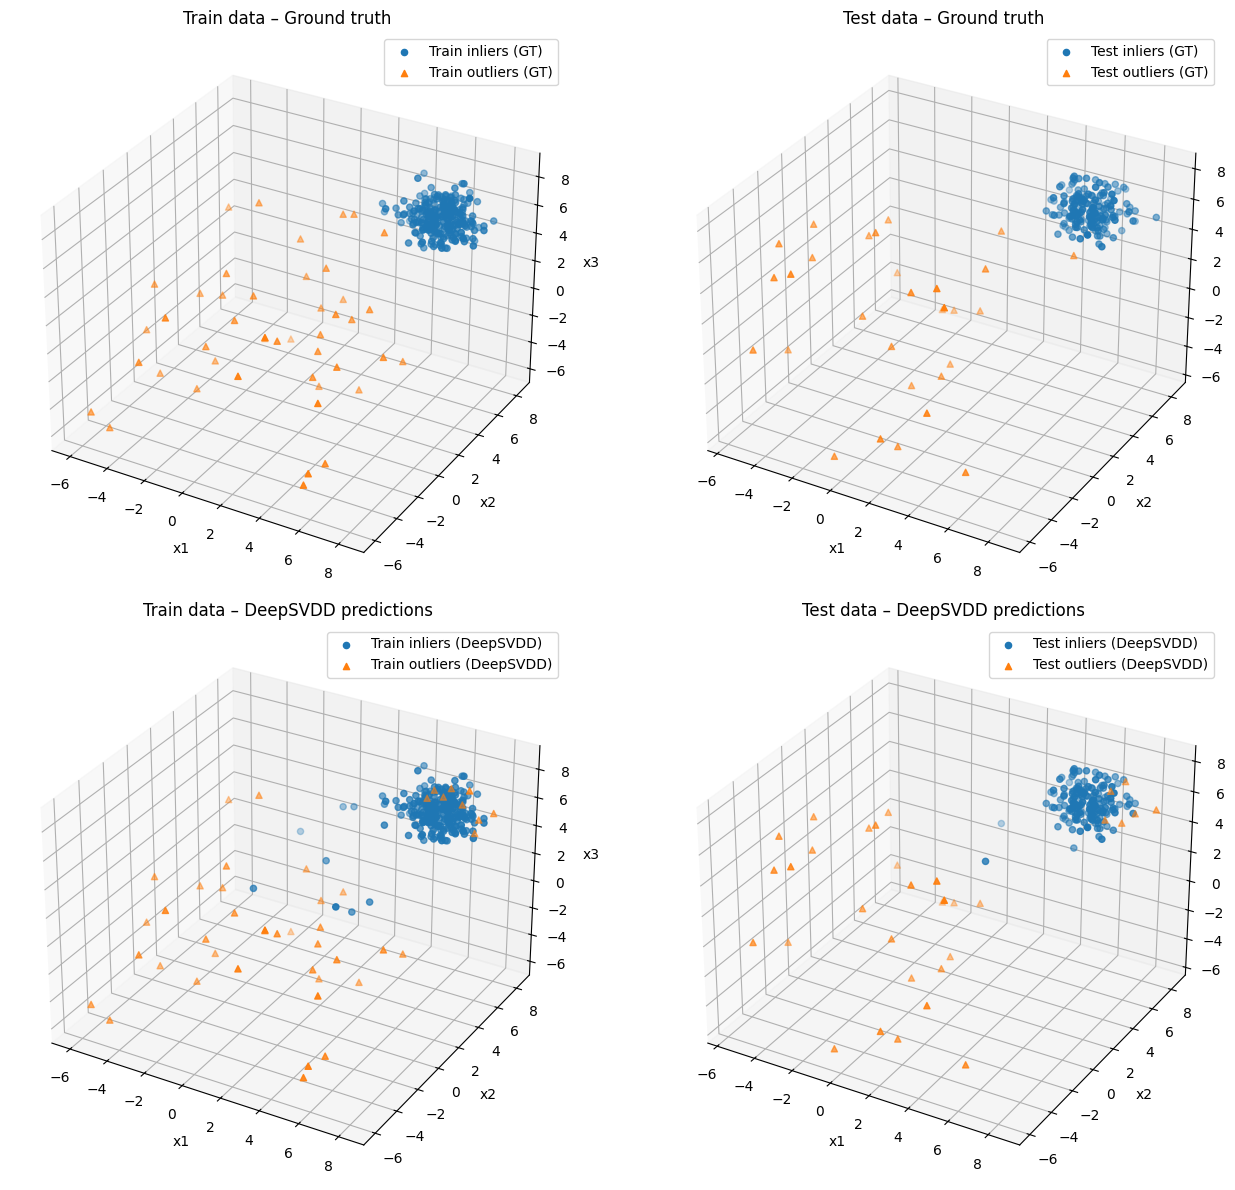

In [9]:
from pyod.models.deep_svdd import DeepSVDD
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  
import numpy as np

n_features = X_train.shape[1]

deep_svdd = DeepSVDD(
    n_features=n_features,
    contamination=contamination,   
    hidden_neurons=[16, 8],        
    epochs=50,
    verbose=0
)

deep_svdd.fit(X_train)

y_train_pred = deep_svdd.predict(X_train)
y_test_pred = deep_svdd.predict(X_test)

y_test_scores = deep_svdd.decision_function(X_test)

ba_deep = balanced_accuracy_score(y_test, y_test_pred)
roc_deep = roc_auc_score(y_test, y_test_scores)

print(f"DeepSVDD - Balanced Accuracy: {ba_deep}")
print(f"DeepSVDD - ROC AUC: {roc_deep}")


train_in_gt = (y_train == 0)
train_out_gt = (y_train == 1)
test_in_gt  = (y_test == 0)
test_out_gt = (y_test == 1)

train_in_pred = (y_train_pred == 0)
train_out_pred = (y_train_pred == 1)
test_in_pred  = (y_test_pred == 0)
test_out_pred = (y_test_pred == 1)

fig = plt.figure(figsize=(14, 12))

ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(X_train[train_in_gt, 0], X_train[train_in_gt, 1], X_train[train_in_gt, 2],
            s=20, label='Train inliers (GT)')
ax1.scatter(X_train[train_out_gt, 0], X_train[train_out_gt, 1], X_train[train_out_gt, 2],
            s=20, marker='^', label='Train outliers (GT)')
ax1.set_title('Train data – Ground truth')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('x3')
ax1.legend()

ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(X_test[test_in_gt, 0], X_test[test_in_gt, 1], X_test[test_in_gt, 2],
            s=20, label='Test inliers (GT)')
ax2.scatter(X_test[test_out_gt, 0], X_test[test_out_gt, 1], X_test[test_out_gt, 2],
            s=20, marker='^', label='Test outliers (GT)')
ax2.set_title('Test data – Ground truth')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.legend()

ax3 = fig.add_subplot(223, projection='3d')
ax3.scatter(X_train[train_in_pred, 0], X_train[train_in_pred, 1], X_train[train_in_pred, 2],
            s=20, label='Train inliers (DeepSVDD)')
ax3.scatter(X_train[train_out_pred, 0], X_train[train_out_pred, 1], X_train[train_out_pred, 2],
            s=20, marker='^', label='Train outliers (DeepSVDD)')
ax3.set_title('Train data – DeepSVDD predictions')
ax3.set_xlabel('x1'); ax3.set_ylabel('x2'); ax3.set_zlabel('x3')
ax3.legend()

ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(X_test[test_in_pred, 0], X_test[test_in_pred, 1], X_test[test_in_pred, 2],
            s=20, label='Test inliers (DeepSVDD)')
ax4.scatter(X_test[test_out_pred, 0], X_test[test_out_pred, 1], X_test[test_out_pred, 2],
            s=20, marker='^', label='Test outliers (DeepSVDD)')
ax4.set_title('Test data – DeepSVDD predictions')
ax4.set_xlabel('x1'); ax4.set_ylabel('x2'); ax4.set_zlabel('x3')
ax4.legend()

plt.tight_layout()
plt.show()


In [11]:
#-----------------------------------EX2-----------------------------------------------------

import numpy as np
from scipy.io import loadmat

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import balanced_accuracy_score

mat = loadmat("cardio 1.mat")

if "X" in mat and "y" in mat:
    X = mat["X"]
    y_pyod = mat["y"].ravel()
else:
    candidates = {k: v for k, v in mat.items() if not k.startswith("__")}
    X = None
    y_pyod = None
    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.ndim == 2 and v.shape[0] > 10 and v.shape[1] > 1:
            X = v
            break
    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.ndim in (1, 2) and v.size == X.shape[0]:
            y_pyod = v.ravel()
            break
    if X is None or y_pyod is None:
        raise ValueError(f"Could not infer X and y from keys: {list(candidates.keys())}")

print("Loaded:", X.shape, y_pyod.shape)
print("Outlier rate (overall):", float(np.mean(y_pyod)))

uniq = np.unique(y_pyod)
if set(uniq.tolist()) == {-1, 1}:
    y_pyod = ((-1 * y_pyod + 1) / 2).astype(int)  
elif set(uniq.tolist()) == {1, 2}:
    y_pyod = (y_pyod == 2).astype(int)
else:
    y_pyod = y_pyod.astype(int)

X_train, X_test, y_train_pyod, y_test_pyod = train_test_split(
    X, y_pyod,
    train_size=0.4,
    random_state=42,
    stratify=y_pyod
)

train_contamination = float(np.mean(y_train_pyod))
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Outlier rate (train):", train_contamination, "Outlier rate (test):", float(np.mean(y_test_pyod)))

y_train_sklearn = np.where(y_train_pyod == 1, -1, 1)
y_test_sklearn  = np.where(y_test_pyod  == 1, -1, 1)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ocsvm", OneClassSVM())
])

param_grid = [
    {
        "ocsvm__kernel": ["linear"],
        "ocsvm__nu": [train_contamination, 0.01, 0.05, 0.1, 0.2, 0.3],
    },
    {
        "ocsvm__kernel": ["rbf", "sigmoid"],
        "ocsvm__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1.0],
        "ocsvm__nu": [train_contamination, 0.01, 0.05, 0.1, 0.2, 0.3],
    },
    {
        "ocsvm__kernel": ["poly"],
        "ocsvm__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1.0],
        "ocsvm__degree": [2, 3, 4],
        "ocsvm__nu": [train_contamination, 0.01, 0.05, 0.1, 0.2, 0.3],
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train_sklearn)

print("\nBest params:", grid.best_params_)
print("Best CV balanced accuracy:", grid.best_score_)

best_model = grid.best_estimator_
y_test_pred = best_model.predict(X_test)  

test_bal_acc = balanced_accuracy_score(y_test_sklearn, y_test_pred)
print("\nTest Balanced Accuracy (best model):", test_bal_acc)


Loaded: (1831, 21) (1831,)
Outlier rate (overall): 0.0961223375204806
Train shape: (732, 21) Test shape: (1099, 21)
Outlier rate (train): 0.09562841530054644 Outlier rate (test): 0.09645131938125569
Fitting 5 folds for each of 186 candidates, totalling 930 fits

Best params: {'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'rbf', 'ocsvm__nu': 0.3}
Best CV balanced accuracy: 0.8694783172806531

Test Balanced Accuracy (best model): 0.8957181401888692


In [12]:
#-----------------------------------EX3-----------------------------------------------------

import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from pyod.utils.utility import standardizer

mat = loadmat("shuttle 1.mat")

if "X" in mat and "y" in mat:
    X = mat["X"]
    y = mat["y"].ravel()
else:
    candidates = {k: v for k, v in mat.items() if not k.startswith("__")}
    X, y = None, None

    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.ndim == 2 and v.shape[0] > 10 and v.shape[1] > 1:
            X = v
            break

    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.size == X.shape[0]:
            y = v.ravel()
            break

    if X is None or y is None:
        raise ValueError(f"Could not infer X and y from keys: {list(candidates.keys())}")

print("Loaded:", X.shape, y.shape)
print("Raw label unique values:", np.unique(y)[:10])

uniq = set(np.unique(y).tolist())

if uniq == {-1, 1}:
    y_pyod = ((-1 * y + 1) / 2).astype(int)  
elif uniq == {1, 2}:
    y_pyod = (y == 2).astype(int)
else:
    y_pyod = y.astype(int)

print("Outlier rate (overall):", float(np.mean(y_pyod)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_pyod,
    test_size=0.5,
    random_state=42,
    stratify=y_pyod
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Outlier rate (train):", float(np.mean(y_train)), "Outlier rate (test):", float(np.mean(y_test)))

X_train_s, X_test_s = standardizer(X_train, X_test)


Loaded: (49097, 9) (49097,)
Raw label unique values: [0 1]
Outlier rate (overall): 0.0715114976475141
Train: (24548, 9) Test: (24549, 9)
Outlier rate (train): 0.07149258595404921 Outlier rate (test): 0.07153040857061388


In [14]:
from pyod.models.ocsvm import OCSVM
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

contamination = float(np.mean(y_train))  

ocsvm = OCSVM(kernel="rbf", contamination=contamination)  
ocsvm.fit(X_train_s)

y_test_pred_ocsvm = ocsvm.predict(X_test_s)                 
y_test_scores_ocsvm = ocsvm.decision_function(X_test_s)     

ba_ocsvm = balanced_accuracy_score(y_test, y_test_pred_ocsvm)
auc_ocsvm = roc_auc_score(y_test, y_test_scores_ocsvm)

print("OCSVM (pyod) - BA:", ba_ocsvm)
print("OCSVM (pyod) - ROC AUC:", auc_ocsvm)


OCSVM (pyod) - BA: 0.974677190285512
OCSVM (pyod) - ROC AUC: 0.9913999442541555


In [15]:
from pyod.models.deep_svdd import DeepSVDD

n_features = X_train_s.shape[1]

deep = DeepSVDD(
    n_features=n_features,
    contamination=contamination,
    hidden_neurons=[64, 32],   
    epochs=30,                 
    verbose=0
)

deep.fit(X_train_s)

y_test_pred_deep = deep.predict(X_test_s)               
y_test_scores_deep = deep.decision_function(X_test_s)   

ba_deep = balanced_accuracy_score(y_test, y_test_pred_deep)
auc_deep = roc_auc_score(y_test, y_test_scores_deep)

print("DeepSVDD (pyod) - BA:", ba_deep)
print("DeepSVDD (pyod) - ROC AUC:", auc_deep)


Epoch 1/30, Loss: 464.5249418094754
Epoch 2/30, Loss: 465.41245353221893
Epoch 3/30, Loss: 464.6717774719
Epoch 4/30, Loss: 464.5564312338829
Epoch 5/30, Loss: 464.56562569737434
Epoch 6/30, Loss: 464.5279211848974
Epoch 7/30, Loss: 464.5413185209036
Epoch 8/30, Loss: 465.53926825523376
Epoch 9/30, Loss: 464.60491836071014
Epoch 10/30, Loss: 464.5735523253679
Epoch 11/30, Loss: 464.55547416210175
Epoch 12/30, Loss: 465.1034530252218
Epoch 13/30, Loss: 464.66414377093315
Epoch 14/30, Loss: 464.59599040448666
Epoch 15/30, Loss: 464.67037259042263
Epoch 16/30, Loss: 464.59491869807243
Epoch 17/30, Loss: 464.5593524724245
Epoch 18/30, Loss: 465.29428508877754
Epoch 19/30, Loss: 464.62677939236164
Epoch 20/30, Loss: 465.06354504823685
Epoch 21/30, Loss: 464.6990258693695
Epoch 22/30, Loss: 464.52214132994413
Epoch 23/30, Loss: 464.6126975119114
Epoch 24/30, Loss: 464.56102265417576
Epoch 25/30, Loss: 464.65589202195406
Epoch 26/30, Loss: 464.54083874821663
Epoch 27/30, Loss: 465.43829192221